Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from patsy.contrasts import Treatment
import statsmodels.formula.api as smf

# Show all columns
pd.set_option('display.max_columns', None)

# Plotting consistencies
plt_edgecolor='black'
plt_color_no_location = 'white'
plt_color_yes_location = 'lightgray'

## Read in the data

In [ ]:
df_raw = pd.read_csv('/content/dev-survey-data.csv')
print(df_raw.columns)

Index(['ResponseId', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'Q1',
       'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q-attention-check', 'Q10',
       'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q18'],
      dtype='object')


In [ ]:
# metadata we want
metadata_cols = [
    'Finished', 'ResponseId', 'Duration (in seconds)',
]

In [ ]:
Qs = [
    'Q1', # consent
    'Q2', # confirm app dev
    'Q3', 'Q4', 'Q5',
    'Q6', #'Q6_24_TEXT', # Country: Other
    'Q7', 'Q8', 'Q-attention-check', 'Q10', 'Q11',
    'Q12', 'Q13', 'Q14', 'Q15','Q18'
]

In [ ]:
# Make a map for Q to text
pd.options.display.max_colwidth = 200
Q_to_text = df_raw[Qs].loc[0].rename('text')
# Make this more readable by replacing '[QID9-ChoiceGroup-SelectedChoices]' and newlines.
app_or_sdk_string = '[QID9-ChoiceGroup-SelectedChoices]'
Q_to_text = Q_to_text.apply(lambda s: s.replace(app_or_sdk_string, 'app/SDK'))
Q_to_text = Q_to_text.apply(lambda s: s.replace('\n', ' '))
display(Q_to_text)
Q_to_text_dict = Q_to_text.to_dict()

,text
Q1,Your responses to this survey may be used in a research publication. All responses will be anonymized and any reports and presentations about the findings from this survey will not include any inf...
Q2,Are you a software developer working on an Android application (app)?
Q3,"Which of the following categories is your app listed as? If you work on more than one App, please answer for your primary App."
Q4,What is your age in years?
Q5,What is your gender?
Q6,Please specify the country where you live. - Selected Choice
Q7,How many years of professional experience do you have as an Android developer?
Q8,"How many Android developers work on your App? If you work on more than one, please answer for your primary App."
Q-attention-check,This is an attention check. Select 2 to 5.
Q10,Do you think Android should make this change and require apps to show users reasons when requesting location access?


In [ ]:
# Drop the metadata to leave only the response data rows
display(df_raw[metadata_cols + Qs].head(3))
df_raw = df_raw[metadata_cols + Qs].drop([0])

,Finished,ResponseId,Duration (in seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q-attention-check,Q10,Q11,Q12,Q13,Q14,Q15,Q18
0,Finished,Response ID,Duration (in seconds),Your responses to this survey may be used in a research publication. All responses will be anonymized and any reports and presentations about the findings from this survey will not include any inf...,Are you a software developer working on an Android application (app)?,"Which of the following categories is your app listed as?\n\nIf you work on more than one App, please answer for your primary App.",What is your age in years?,What is your gender?,Please specify the country where you live. - Selected Choice,How many years of professional experience do you have as an Android developer?,"How many Android developers work on your App?\nIf you work on more than one, please answer for your primary App.",This is an attention check. Select 2 to 5.,Do you think Android should make this change and require apps to show users reasons when requesting location access?,"What are your concerns, if any, for this hypothetical change?",How do you think this change would impact how often users grant apps location access (vs “Don’t allow”)?,What impact do you think this change would have on user privacy?,What impact do you think this change would have on users’ trust for apps that request location access?,What impact do you think this change would have on users’ trust for the Android platform?,Does your app request the user’s location?
1,TRUE,R_7uaVonnr0ynU1aN,109,Continue,"Yes, I am an Android developer working on an app",Entertainment,35 - 44,Man,Canada,6 to 9 years,Just myself,2 to 5,No,I don't really think most people bother reading,It will have no impact,Neutral,Neutral,Neutral,No
2,TRUE,R_1vqX6XKT6I5gunT,112,Continue,"Yes, I am an Android developer working on an app",Entertainment,35 - 44,Man,United States,15+ years,25 - 49,2 to 5,Yes,developers may lie about reasons,It will increase how often users grant location access,Negative impact on user privacy,Improve trust for apps,Improve trust for Android,No


## Filtering

In [ ]:
print('%s total survey responses' % len(df_raw))
print('Discarding %s incomplete responses' % len(df_raw[df_raw['Finished'] != 'TRUE']))
# Discard unfinished responses
df = df_raw[df_raw['Finished'] == 'TRUE'].drop('Finished', axis=1)
print('%s completed survey responses' % len(df))
# Check consent
print('%s did not consent to survey. Dropping these responses.' % (df['Q1'].apply(lambda c: 'Exit' in str(c)).sum()))
df = df[~df['Q1'].apply(lambda c: 'Exit' in str(c))].set_index('ResponseId')
print('n=%s' % len(df))

353 total survey responses
Discarding 6 incomplete responses
347 completed survey responses
0 did not consent to survey. Dropping these responses.
n=347


In [ ]:
# Discard responses from participants who responded that they are not Android *app* developers
Q = 'Q2'
print(Q_to_text_dict[Q])
display(df[Q].value_counts())
not_app_dev = df[Q].apply(lambda s: (('No, ' in str(s)) or 'nan' in str(s)))
print('Dropping %s responses from participants who are not Android app developers' % len(df[not_app_dev]))
df = df[~not_app_dev]

Are you a software developer working on an Android application (app)?


,count
Q2,
"Yes, I am an Android developer working on an app",326
"No, I am not an Android developer",20
"No, I am an Android developer but I work on an SDK; I do not work on an app",1


Dropping 21 responses from participants who are not Android app developers


In [ ]:
# Attention check failures.
Q_attn_check_correct = '2 to 5'
# display(df[Q_attn_check])
print('Discarding %s attention check failures' % len(df[df['Q-attention-check'] != Q_attn_check_correct]))
df = df[df['Q-attention-check'] == Q_attn_check_correct]

Discarding 3 attention check failures


In [ ]:
N = len(df)
print('N = %s' % N)
df.head(3)

N = 323


,Duration (in seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q-attention-check,Q10,Q11,Q12,Q13,Q14,Q15,Q18
ResponseId,,,,,,,,,,,,,,,,,
R_7uaVonnr0ynU1aN,109,Continue,"Yes, I am an Android developer working on an app",Entertainment,35 - 44,Man,Canada,6 to 9 years,Just myself,2 to 5,No,I don't really think most people bother reading,It will have no impact,Neutral,Neutral,Neutral,No
R_1vqX6XKT6I5gunT,112,Continue,"Yes, I am an Android developer working on an app",Entertainment,35 - 44,Man,United States,15+ years,25 - 49,2 to 5,Yes,developers may lie about reasons,It will increase how often users grant location access,Negative impact on user privacy,Improve trust for apps,Improve trust for Android,No
R_80C8n5WcJi7MpeN,439,Continue,"Yes, I am an Android developer working on an app",Productivity,45 - 54,Man,United Kingdom,15+ years,2 - 4,2 to 5,Yes,"It's always good for the users to know why the device location is needed BUT again, developers can tell lies which may not fully disclose the whole story, or even present a false narrative for the...",It will increase how often users grant location access,Neutral,Improve trust for apps,Neutral,No


## Developer demographics, etc

Survey duration

,Duration (mins)
count,323.0
mean,23.0
std,176.3
min,1.2
25%,3.9
50%,5.9
75%,9.6
max,2865.4


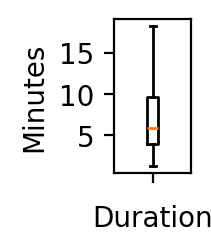

In [ ]:
duration_mins =  (df['Duration (in seconds)'].astype(int)/60).rename('Duration (mins)')
fig,ax = plt.subplots(1,1,figsize=(0.5,1), dpi=200)
ax.set_xlabel('Duration')
ax.set_ylabel('Minutes')
ax.boxplot(duration_mins, showfliers=False, tick_labels=[''])
duration_mins.describe().round(1)

### Age, gender, country

What is your age in years?


,n,pct
Q4,,
18 - 24,5,1.5
25 - 34,59,18.3
35 - 44,95,29.4
45 - 54,115,35.6
55 - 64,33,10.2
65 or older,14,4.3
Prefer not to say,2,0.6


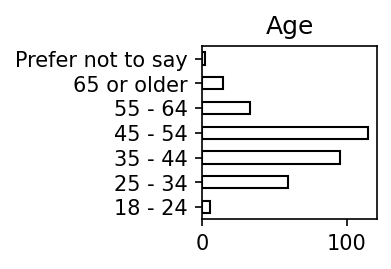

In [ ]:
Q = 'Q4'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().loc[
    ['18 - 24', '25 - 34', '35 - 44', '45 - 54', '55 - 64', '65 or older', 'Prefer not to say']
].rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
display(d)
fig, ax = plt.subplots(1,1, figsize=(1.5,1.5), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor)
ax.set_title('Age')
_ = ax.set_ylabel('')

What is your gender?


,n,pct
Q5,,
Man,299,92.6
Woman,14,4.3
Prefer not to say,8,2.5
Other,2,0.6


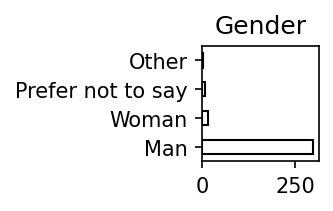

In [ ]:
Q = 'Q5'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
display(d)
fig, ax = plt.subplots(1,1, figsize=(1,1), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor)
ax.set_title('Gender')
_ = ax.set_ylabel('')

Please specify the country where you live. - Selected Choice


,n,pct
Q6,,
United States,152,47.1
United Kingdom,48,14.9
Canada,38,11.8
Germany,32,9.9
Netherlands,14,4.3
Finland,9,2.8
Sweden,8,2.5
Australia,6,1.9
Ireland,5,1.5


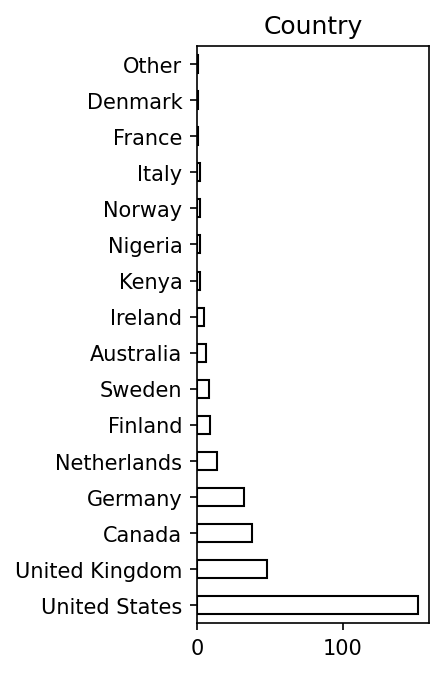

In [ ]:
Q = 'Q6'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)).rename(index={
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'United States of America': 'USA'
    })
display(d)
fig, ax = plt.subplots(1,1, figsize=(2,5), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor)
ax.set_title('Country')
_ = ax.set_ylabel('')


Professional experience and team size.

How many years of professional experience do you have as an Android developer?


,n,pct
Q7,,
Less than 1 year,3,0.9
1 to 2 years,26,8.0
3 to 5 years,57,17.6
6 to 9 years,75,23.2
10 to 14 years,111,34.4
15+ years,51,15.8


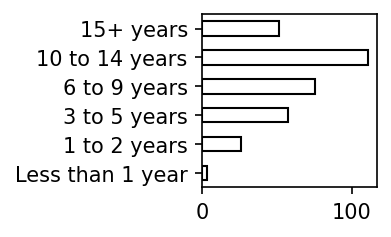

In [ ]:
Q = 'Q7'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().loc[
    ['Less than 1 year', '1 to 2 years', '3 to 5 years', '6 to 9 years', '10 to 14 years',  '15+ years']
].rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
display(d)
fig, ax = plt.subplots(1,1, figsize=(1.5,1.5), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor)
_ = ax.set_ylabel('')

How many Android developers work on your App? If you work on more than one, please answer for your primary App.


,n,pct
Q8,,
Just myself,152,47.1
2 - 4,116,35.9
5 - 9,25,7.7
10 - 24,16,5.0
25 - 49,5,1.5
50 or more,9,2.8


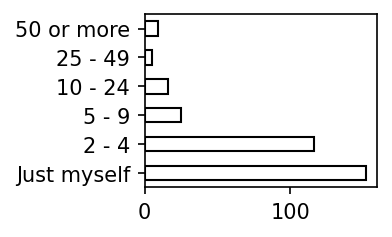

In [ ]:
Q = 'Q8'
print(Q_to_text_dict[Q])
d = df[Q].value_counts().loc[['Just myself', '2 - 4', '5 - 9', '10 - 24',  '25 - 49', '50 or more']].rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
display(d)
fig, ax = plt.subplots(1,1, figsize=(2,1.5), dpi=150)
_ = d.n.plot.barh(ax, color='white', edgecolor='black')
_ = ax.set_ylabel('')

#### Set up demographic variables for regression analysis by compressing them to fewer variables.

Gender: Male vs non-male

Age3: Map 6 categories to 3

TeamSize3: Map to 3 categories

Exp3: Map Professional Experience to 3 variables

In [ ]:
gender_map = {
    'Man': 'Male',
    'Woman': 'Non-male',
    'Prefer not to say': 'Non-male',
    'Other': 'Non-male',
}
age3_map = {
  'Prefer not to say': 'Prefer not to say',
  '18 - 24': '18 - 34',
  '25 - 34': '18 - 34',
  '35 - 44': '35 - 54',
  '45 - 54': '35 - 54',
  '55 - 64': '55+',
  '65 or older': '55+',
}
team_size3_map = {
  'Just myself':'1',
  '2 - 4': '2 - 9',
  '5 - 9': '2 - 9',
  '10 - 24': '10 or more',
  '25 - 49': '10 or more',
  '50 or more': '10 or more',
}
exp3_map = {
    'Less than 1 year': 'Less than 3 years',
    '1 to 2 years': 'Less than 3 years',
    '3 to 5 years': '3 - 9 years',
    '6 to 9 years': '3 - 9 years',
    '10 to 14 years': '10+ years',
    '15+ years': '10+ years',
}
df['Age3'] = df['Q4'].map(age3_map)
df['Gender'] = df['Q5'].map(gender_map)
df['Exp3'] = df['Q7'].map(exp3_map)
df['TeamSize3'] = df['Q8'].map(team_size3_map)
display(df['Gender'].value_counts().sort_index().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)))
display(df['Age3'].value_counts().sort_index().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)))

display(df['TeamSize3'].value_counts().sort_values(ascending=False))
display(df['Exp3'].value_counts().sort_index(ascending=False))
df[['Gender', 'Age3', 'TeamSize3', 'Exp3']].head(3)

,n,pct
Gender,,
Male,299,92.6
Non-male,24,7.4


,n,pct
Age3,,
18 - 34,64,19.8
35 - 54,210,65.0
55+,47,14.6
Prefer not to say,2,0.6


,count
TeamSize3,
1,152
2 - 9,141
10 or more,30


,count
Exp3,
Less than 3 years,29
3 - 9 years,132
10+ years,162


,Gender,Age3,TeamSize3,Exp3
ResponseId,,,,
R_7uaVonnr0ynU1aN,Male,35 - 54,1,3 - 9 years
R_1vqX6XKT6I5gunT,Male,35 - 54,10 or more,10+ years
R_80C8n5WcJi7MpeN,Male,35 - 54,2 - 9,10+ years


#### Q18-use-location: Does your app request the user’s location?


In [ ]:
"""
Make a table with counts and percentages for number of apps that
- request location
- request precise location
"""
print('N=%s' % N)
Q_request_location = 'Q18'

d = pd.DataFrame({
    'Requests location': df[Q_request_location].value_counts(),
}).fillna(0).astype(int).transpose()
d['Yes %'] = round(100*d['Yes']/N,1)
d['No %'] = round(100*d['No']/N,1)
d = d[['Yes', 'Yes %', 'No', 'No %', "I don’t know"]]
d

N=323


Q18,Yes,Yes %,No,No %,I don’t know
Requests location,114,35.3,206,63.8,3


In [ ]:
# Add indicator variable: uses_location: True if answer to Q18 is True (requests either precise or approx location)
df['uses_location'] = (df[Q_request_location]=='Yes')
display(df[['uses_location']].value_counts())
n_use_location = df['uses_location'].sum()
n_do_not_use_location = N - n_use_location
print('N=%s use location' % n_use_location)
print('N=%s do not use location (or do not know)' % n_do_not_use_location)

,count
uses_location,
False,209
True,114


N=114 use location
N=209 do not use location (or do not know)


### App category

In [ ]:
Q_app_category = 'Q3'
Q = Q_app_category

print(Q_to_text_dict[Q])
d = (df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
.join(df[df['uses_location']][Q_app_category].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1)),
  rsuffix=': uses_location')
.fillna(0)
)
d

Which of the following categories is your app listed as?  If you work on more than one App, please answer for your primary App.


,n,pct,n: uses_location,pct: uses_location
Q3,,,,
Games,56,17.3,7.0,2.2
Productivity,38,11.8,14.0,4.3
Entertainment,25,7.7,4.0,1.2
Tools,24,7.4,5.0,1.5
Health and Fitness,21,6.5,12.0,3.7
Business,21,6.5,12.0,3.7
Education,19,5.9,5.0,1.5
Communications,14,4.3,6.0,1.9
Finance,13,4.0,2.0,0.6


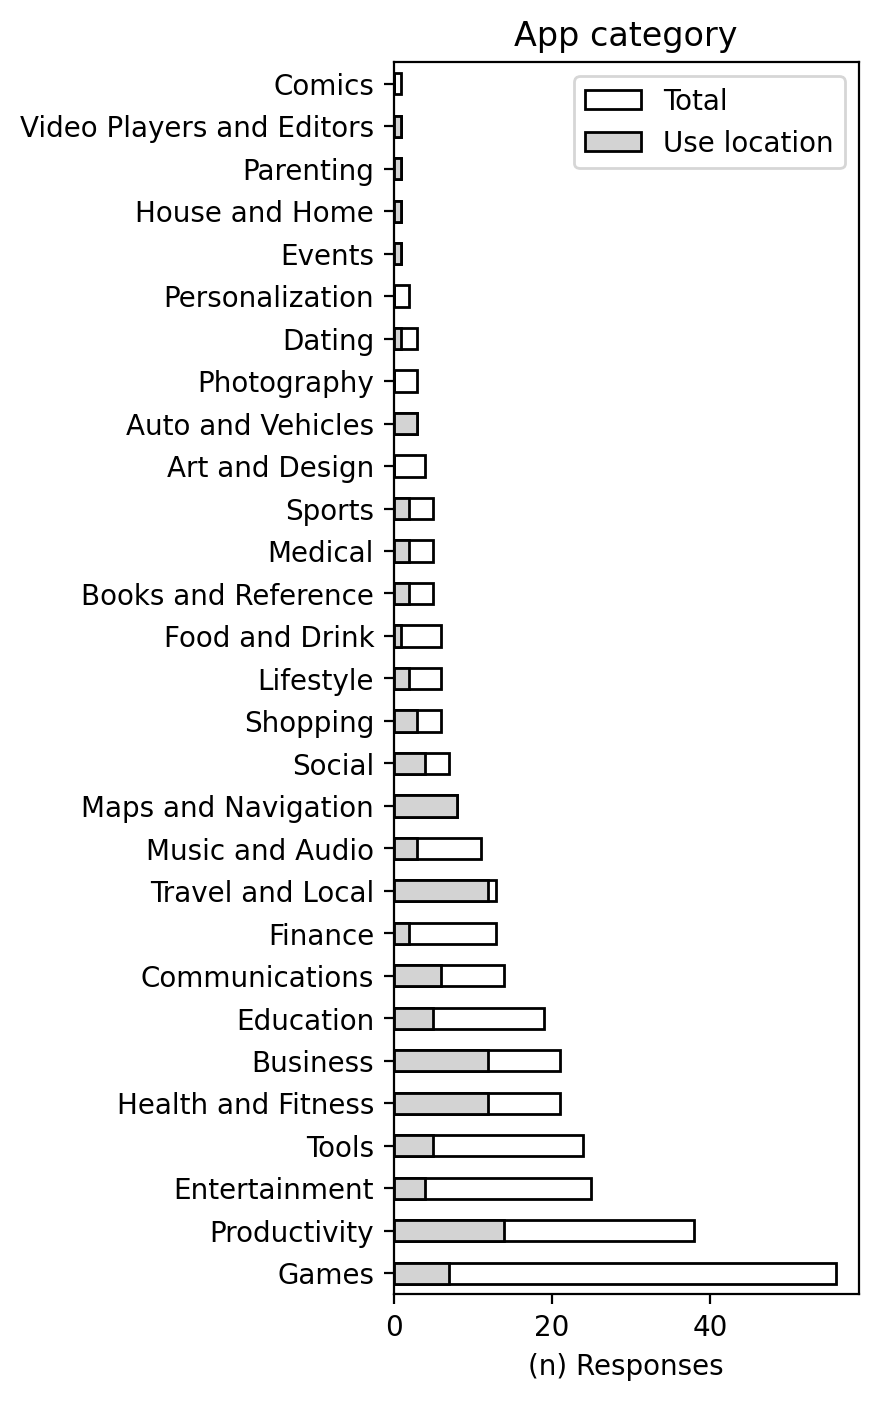

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(3,8), dpi=200)
d.n.plot.barh(ax, color='white', edgecolor=plt_edgecolor, label='Total')
d['n: uses_location'].plot.barh(ax, color=plt_color_yes_location, edgecolor=plt_edgecolor, label='Use location')
ax.set_title('App category')
ax.set_xlabel('(n) Responses')
ax.legend()
_ = ax.set_ylabel('')
plt.show()

## Responses about purpose strings

Our survey states:
```
  The following survey questions ask you about a hypothetical change to the Android ecosystem:

  Apps that request access to users’ locations will be required to show a reason to the user.

  An example explaining this change is shown below.
```


Do you think Android should make this change and require apps to show users reasons when requesting location access?


,n,pct,n: use location,pct: use location,n: do not use location,pct: do not use location
Q10,,,,,,
Yes,279,86.4,98,86.0,181,86.6
No,44,13.6,16,14.0,28,13.4


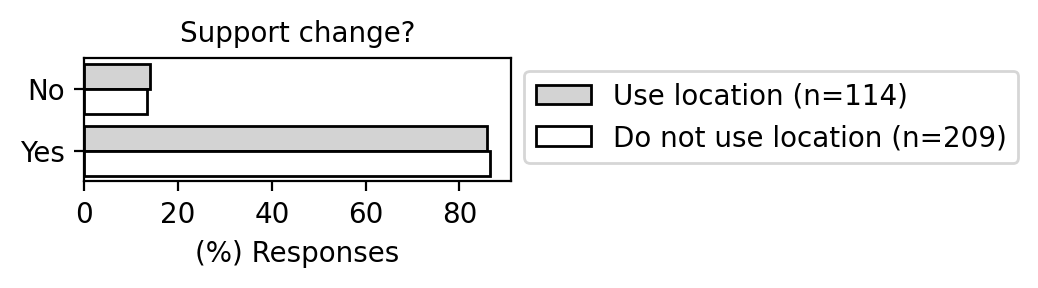

In [ ]:
Q = 'Q10'
print(Q_to_text_dict[Q])

df_support_change = (df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
.join(df[df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_use_location, 1)), rsuffix=': use location')
.join(df[~df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_do_not_use_location, 1)), rsuffix=': do not use location'))
display(df_support_change)
# plot
width = 0.4
ind = np.arange(2)
fig, ax = plt.subplots(1,1,figsize=(2.75,0.8), dpi=200)
ax.barh(ind + width, df_support_change['pct: use location'], width, label='Use location (n=%s)'%n_use_location, color=plt_color_yes_location, edgecolor=plt_edgecolor)
ax.barh(ind, df_support_change['pct: do not use location'], width, label='Do not use location (n=%s)'%n_do_not_use_location, color=plt_color_no_location, edgecolor=plt_edgecolor)
ax.set(yticks=ind+(width/2), yticklabels=['Yes', 'No'])
ax.set_xlabel('(%) Responses')
ax.set_title('Support change?', fontsize=10)
_ = ax.legend(bbox_to_anchor=(1, 1.01))


### What do developers think?

How do you think this change would impact how often users grant apps location access (vs “Don’t allow”)?


,n,pct,n: use location,pct: use location,n: do not use location,pct: do not use location
Q12,,,,,,
It will increase how often users grant location access,155,48.0,55,48.2,100,47.8
It will have no impact,105,32.5,41,36.0,64,30.6
It will decrease how often users grant location access,63,19.5,18,15.8,45,21.5


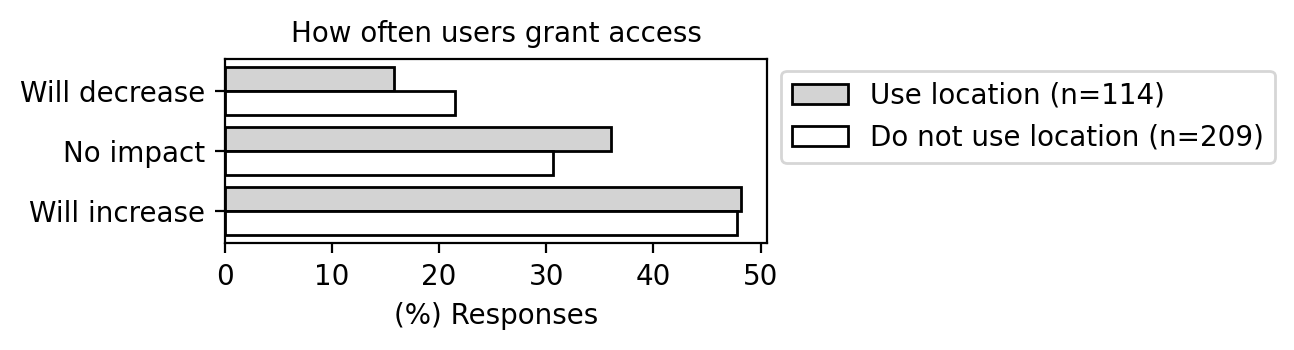

In [ ]:
Q_impact_grant_access = 'Q12'
Q = Q_impact_grant_access
print(Q_to_text_dict[Q])

df_Q_grant = (df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
.join(df[df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_use_location, 1)), rsuffix=': use location')
.join(df[~df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_do_not_use_location, 1)), rsuffix=': do not use location'))
display(df_Q_grant)
# plot
width = 0.4
ind = np.arange(3)
fig, ax = plt.subplots(1,1,figsize=(3.5,1.2), dpi=200)
ax.barh(ind + width, df_Q_grant['pct: use location'], width, label='Use location (n=%s)'%n_use_location, color=plt_color_yes_location, edgecolor=plt_edgecolor)
ax.barh(ind, df_Q_grant['pct: do not use location'], width, label='Do not use location (n=%s)'%n_do_not_use_location, color=plt_color_no_location, edgecolor=plt_edgecolor)
ax.set(yticks=ind+(width/2), yticklabels=['Will increase', 'No impact', 'Will decrease'])
ax.set_xlabel('(%) Responses')
ax.set_title('How often users grant access', fontsize=10)
_ = ax.legend(bbox_to_anchor=(1, 1.01))


What impact do you think this change would have on user privacy?


,n,pct,n: use location,pct: use location,n: do not use location,pct: do not use location
Q13,,,,,,
Very positive impact on user privacy,65.0,20.1,23.0,20.2,42.0,20.1
Positive impact on user privacy,152.0,47.1,47.0,41.2,105.0,50.2
Neutral,101.0,31.3,43.0,37.7,58.0,27.8
Negative impact on user privacy,5.0,1.5,1.0,0.9,4.0,1.9
Very negative impact on user privacy,0.0,0.0,0.0,0.0,0.0,0.0


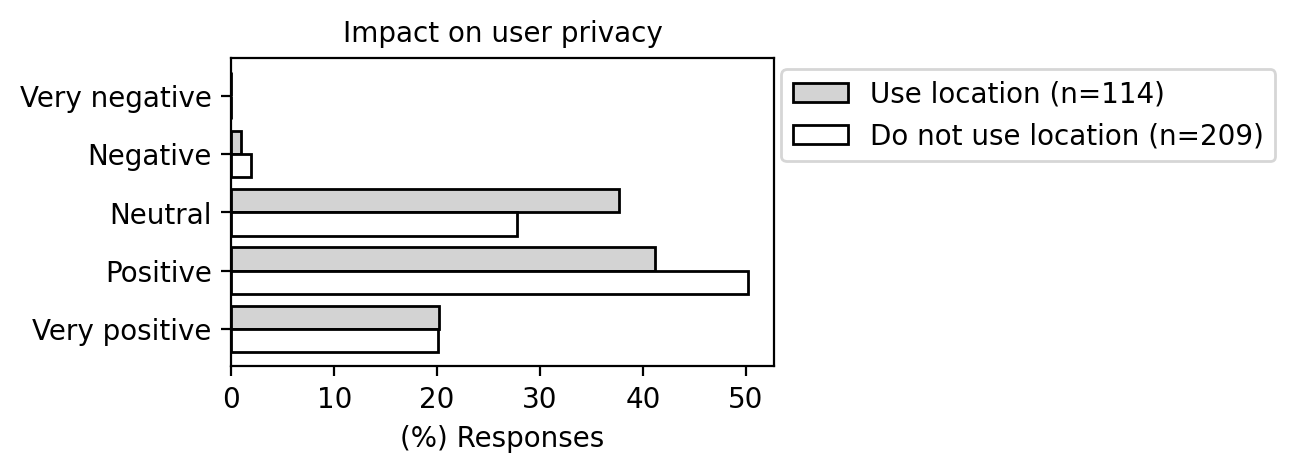

In [ ]:
Q_impact_privacy = 'Q13'
Q = Q_impact_privacy
print(Q_to_text_dict[Q])

# labels used to reindex need to match the current index
labels = [
  'Very positive impact on user privacy',
  'Positive impact on user privacy',
  'Neutral',
  'Negative impact on user privacy',
  'Very negative impact on user privacy'
]
short_labels = [
  'Very positive',
  'Positive',
  'Neutral',
  'Negative',
  'Very negative'
]
df_Q_privacy = (df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
.join(df[df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_use_location, 1)), rsuffix=': use location')
.join(df[~df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_do_not_use_location, 1)), rsuffix=': do not use location'))
# No one said very negative impact, so we just add it in with 0's
df_Q_privacy = df_Q_privacy.reindex(labels).fillna(0)
display(df_Q_privacy)
# plot
width = 0.4
ind = np.arange(5)
fig, ax = plt.subplots(1,1,figsize=(3.5,2), dpi=200)
ax.barh(ind + width, df_Q_privacy['pct: use location'], width, label='Use location (n=%s)'%n_use_location, color=plt_color_yes_location, edgecolor=plt_edgecolor)
ax.barh(ind, df_Q_privacy['pct: do not use location'], width, label='Do not use location (n=%s)'%n_do_not_use_location, color=plt_color_no_location, edgecolor=plt_edgecolor)
ax.set(yticks=ind+(width/2), yticklabels=short_labels)
ax.set_xlabel('(%) Responses')
ax.set_title('Impact on user privacy', fontsize=10)
_ = ax.legend(bbox_to_anchor=(1.95, 1.01))


What impact do you think this change would have on users’ trust for apps that request location access?


,n,pct,n: use location,pct: use location,n: do not use location,pct: do not use location
Q14,,,,,,
Greatly improve trust for apps,59.0,18.3,15.0,13.2,44.0,21.1
Improve trust for apps,194.0,60.1,73.0,64.0,121.0,57.9
Neutral,57.0,17.6,21.0,18.4,36.0,17.2
Reduce trust for apps,13.0,4.0,5.0,4.4,8.0,3.8
Greatly reduce trust for apps,0.0,0.0,0.0,0.0,0.0,0.0


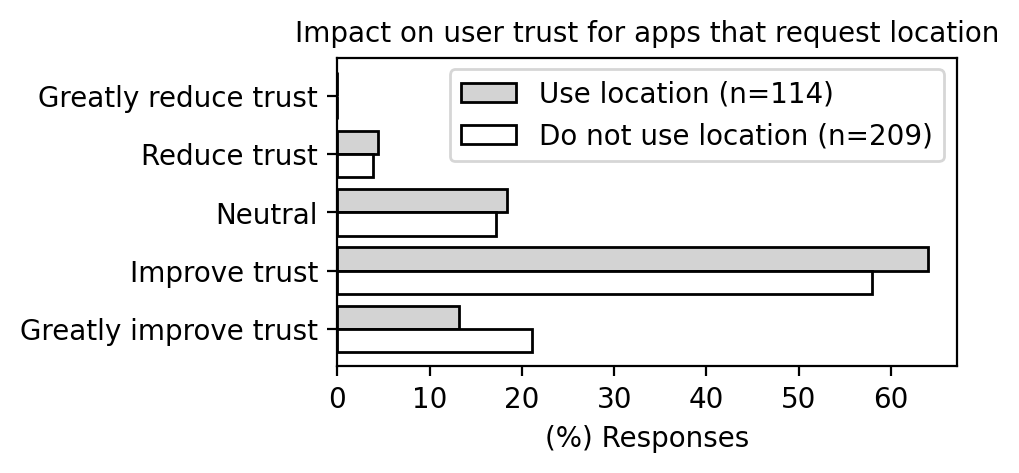

In [ ]:
Q_impact_trust_apps = 'Q14'
Q = Q_impact_trust_apps
print(Q_to_text_dict[Q])

# labels used to reindex need to match the current index
labels = [
    'Greatly improve trust for apps',
    'Improve trust for apps',
    'Neutral',
    'Reduce trust for apps',
    'Greatly reduce trust for apps'
]
short_labels = [
    'Greatly improve trust',
    'Improve trust',
    'Neutral',
    'Reduce trust',
    'Greatly reduce trust'
]
df_Q_apps = (df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
.join(df[df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_use_location, 1)), rsuffix=': use location')
.join(df[~df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_do_not_use_location, 1)), rsuffix=': do not use location'))
# No one said very negative impact, so we just add it in with 0's
df_Q_apps = df_Q_apps.reindex(labels).fillna(0)
display(df_Q_apps)
# plot
width = 0.4
ind = np.arange(5)
fig, ax = plt.subplots(1,1,figsize=(4,2), dpi=200)
ax.barh(ind + width, df_Q_apps['pct: use location'], width, label='Use location (n=%s)'%n_use_location, color=plt_color_yes_location, edgecolor=plt_edgecolor)
ax.barh(ind, df_Q_apps['pct: do not use location'], width, label='Do not use location (n=%s)'%n_do_not_use_location, color=plt_color_no_location, edgecolor=plt_edgecolor)
ax.set(yticks=ind+(width/2), yticklabels=short_labels)
ax.set_xlabel('(%) Responses')
ax.set_title('Impact on user trust for apps that request location', fontsize=10)
_ = ax.legend(bbox_to_anchor=(1, 1.01))


What impact do you think this change would have on users’ trust for the Android platform?


,n,pct,n: use location,pct: use location,n: do not use location,pct: do not use location
Q15,,,,,,
Greatly improve trust for Android,57.0,17.6,17.0,14.9,40.0,19.1
Improve trust for Android,172.0,53.3,61.0,53.5,111.0,53.1
Neutral,86.0,26.6,31.0,27.2,55.0,26.3
Reduce trust for Android,8.0,2.5,5.0,4.4,3.0,1.4
Greatly reduce trust for Android,0.0,0.0,0.0,0.0,0.0,0.0


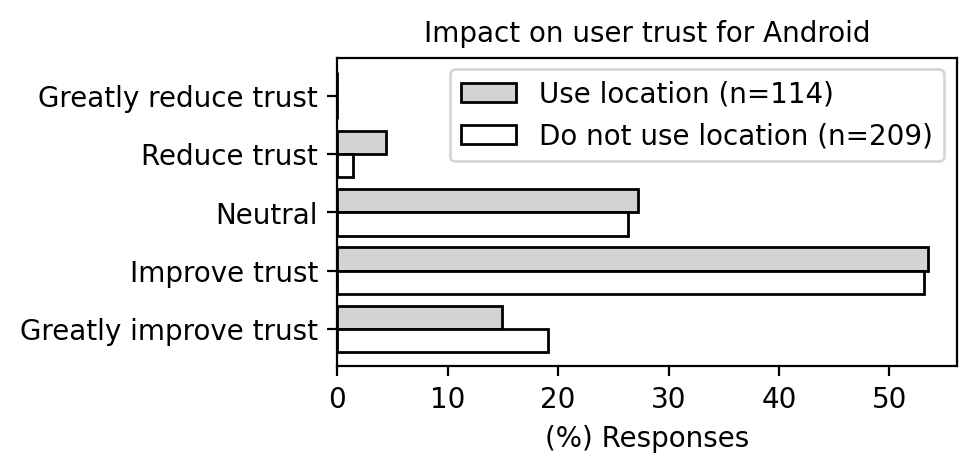

In [ ]:
Q_impact_trust_android = 'Q15'
Q = Q_impact_trust_android
print(Q_to_text_dict[Q])

# labels used to reindex need to match the current index
labels = [
    'Greatly improve trust for Android',
    'Improve trust for Android',
    'Neutral',
    'Reduce trust for Android',
    'Greatly reduce trust for Android'
]
short_labels = [
    'Greatly improve trust',
    'Improve trust',
    'Neutral',
    'Reduce trust',
    'Greatly reduce trust'
]
df_Q_android = (df[Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/N, 1))
.join(df[df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_use_location, 1)), rsuffix=': use location')
.join(df[~df['uses_location']][Q].value_counts().rename('n').to_frame().assign(pct= lambda x: round(100*x.n/n_do_not_use_location, 1)), rsuffix=': do not use location'))
# No one said very negative impact, so we just add it in with 0's
df_Q_android = df_Q_android.reindex(labels).fillna(0)
display(df_Q_android)
# plot
width = 0.4
ind = np.arange(5)
fig, ax = plt.subplots(1,1,figsize=(4,2), dpi=200)
ax.barh(ind + width, df_Q_android['pct: use location'], width, label='Use location (n=%s)'%n_use_location, color=plt_color_yes_location, edgecolor=plt_edgecolor)
ax.barh(ind, df_Q_android['pct: do not use location'], width, label='Do not use location (n=%s)'%n_do_not_use_location, color=plt_color_no_location, edgecolor=plt_edgecolor)
ax.set(yticks=ind+(width/2), yticklabels=short_labels)
ax.set_xlabel('(%) Responses')
ax.set_title('Impact on user trust for Android', fontsize=10)
_ = ax.legend(bbox_to_anchor=(1, 1.01))


What impact do developers believe this change will have on user trust?


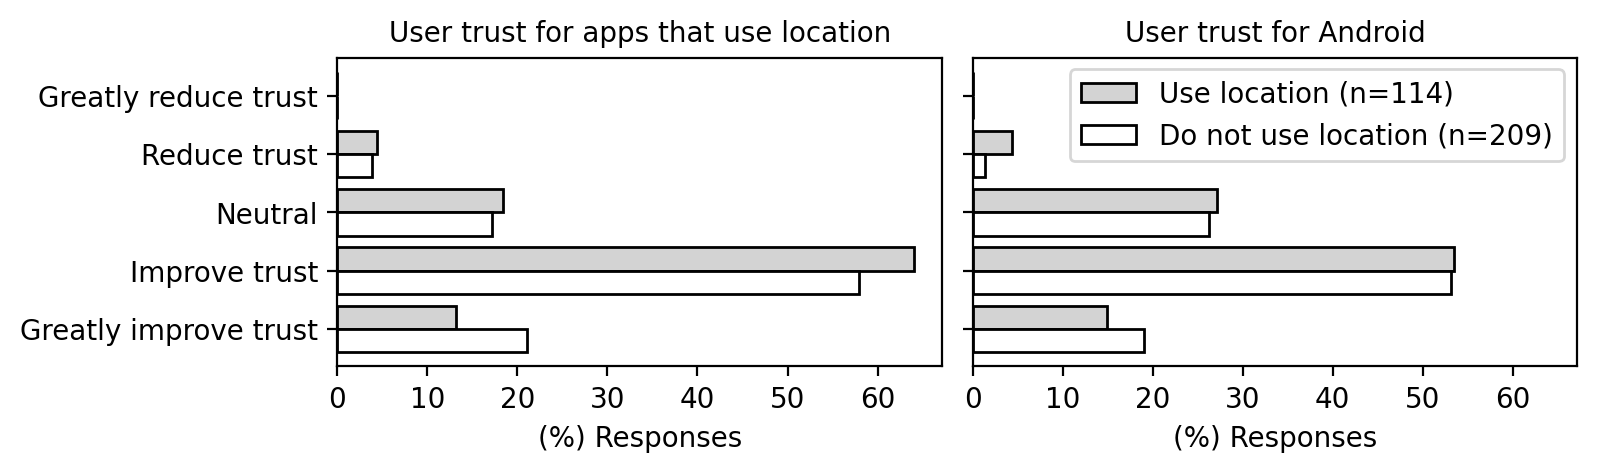

In [ ]:
print('What impact do developers believe this change will have on user trust?')
# Plot together
width = 0.4
ind = np.arange(5)
fig, (ax1,ax2) = plt.subplots(1, 2,figsize=(8,2), dpi=200, sharex=True, sharey=True)
ax1.barh(ind + width, df_Q_apps['pct: use location'], width, label='Use location (n=%s)'%n_use_location, color=plt_color_yes_location, edgecolor=plt_edgecolor)
ax1.barh(ind, df_Q_apps['pct: do not use location'], width, label='Do not use location (n=%s)'%n_do_not_use_location, color=plt_color_no_location, edgecolor=plt_edgecolor)
ax1.set(yticks=ind+(width/2), yticklabels=short_labels)
ax1.set_xlabel('(%) Responses')
ax1.set_title('User trust for apps that use location', fontsize=10)
ax2.barh(ind + width, df_Q_android['pct: use location'], width, label='Use location (n=%s)'%n_use_location, color=plt_color_yes_location, edgecolor=plt_edgecolor)
ax2.barh(ind, df_Q_android['pct: do not use location'], width, label='Do not use location (n=%s)'%n_do_not_use_location, color=plt_color_no_location, edgecolor=plt_edgecolor)
ax2.set_xlabel('(%) Responses')
ax2.set_title('User trust for Android', fontsize=10)
plt.subplots_adjust(wspace=0.05)
_ = ax2.legend(bbox_to_anchor=(1, 1.01))

#### Regression analysis

We try this 2 different ways for the Likert-scale questions.

1.
The first way converts the 5-point Likert-scale questions to 3 levels (-1/0/1).
We do this for improved interpretability of the regression results.


2.
The second way keeps the 5 levels (-2,-1,0,1,2).


Dependent variable: support change

independent variables:
- Uses location
- Impact on user privacy
- Impact on granting access
- Impact on granting access x uses location (not significant)
- Impact on user trust for Android
- Impact on user trust for apps
- User trust for apps x uses location (not significant)


In [ ]:
# Map likert Q responses to numeric scale

# Scales centered around neutral: 0
Q_impact_grant_access_int_map = {
  'It will increase how often users grant location access': 1,
  'It will have no impact': 0,
  'It will decrease how often users grant location access': -1
}
Q_impact_privacy_int_map = {
  'Very positive impact on user privacy': 2,
  'Positive impact on user privacy': 1,
  'Neutral': 0,
  'Negative impact on user privacy': -1,
  'Very negative impact on user privacy': -2
}
Q_impact_trust_apps_int_map = {
    'Greatly improve trust for apps': 2,
    'Improve trust for apps': 1,
    'Neutral': 0,
    'Reduce trust for apps': -1,
    'Greatly reduce trust for apps': -2
}
Q_impact_trust_android_int_map = {
    'Greatly improve trust for Android': 2,
    'Improve trust for Android': 1,
    'Neutral': 0,
    'Reduce trust for Android': -1,
    'Greatly reduce trust for Android': -2
}
Q_impact_privacy_int_map_3 = {
  'Very positive impact on user privacy': 1,
  'Positive impact on user privacy': 1,
  'Neutral': 0,
  'Negative impact on user privacy': -1,
  'Very negative impact on user privacy': -1
}
Q_impact_trust_apps_int_map_3 = {
    'Greatly improve trust for apps': 1,
    'Improve trust for apps': 1,
    'Neutral': 0,
    'Reduce trust for apps': -1,
    'Greatly reduce trust for apps': -1
}
Q_impact_trust_android_int_map_3 = {
    'Greatly improve trust for Android': 1,
    'Improve trust for Android': 1,
    'Neutral': 0,
    'Reduce trust for Android': -1,
    'Greatly reduce trust for Android': -1
}
df['impact_grant_access'] = df[Q_impact_grant_access].map(Q_impact_grant_access_int_map)
df['impact_privacy'] = df[Q_impact_privacy].map(Q_impact_privacy_int_map)
df['impact_trust_apps'] = df[Q_impact_trust_apps].map(Q_impact_trust_apps_int_map)
df['impact_trust_android'] = df[Q_impact_trust_android].map(Q_impact_trust_android_int_map)
df['impact_privacy_3'] = df[Q_impact_privacy].map(Q_impact_privacy_int_map_3)
df['impact_trust_apps_3'] = df[Q_impact_trust_apps].map(Q_impact_trust_apps_int_map_3)
df['impact_trust_android_3'] = df[Q_impact_trust_android].map(Q_impact_trust_android_int_map_3)
df[['impact_grant_access', 'impact_privacy', 'impact_trust_apps', 'impact_trust_android', 'impact_privacy_3', 'impact_trust_apps_3', 'impact_trust_android_3', Q_impact_grant_access, Q_impact_privacy, Q_impact_trust_apps, Q_impact_trust_android]].head(3)

,impact_grant_access,impact_privacy,impact_trust_apps,impact_trust_android,impact_privacy_3,impact_trust_apps_3,impact_trust_android_3,Q12,Q13,Q14,Q15
ResponseId,,,,,,,,,,,
R_7uaVonnr0ynU1aN,0,0,0,0,0,0,0,It will have no impact,Neutral,Neutral,Neutral
R_1vqX6XKT6I5gunT,1,-1,1,1,-1,1,1,It will increase how often users grant location access,Negative impact on user privacy,Improve trust for apps,Improve trust for Android
R_80C8n5WcJi7MpeN,1,0,1,0,0,1,0,It will increase how often users grant location access,Neutral,Improve trust for apps,Neutral


In [ ]:
# Add variable indicating dev supports change
df['support_change'] = (df['Q10']=='Yes')

In [ ]:
# displaying / printing helpers
def get_stars(row):
    if row['p-value'] < 0.001:
        return '***'
    if row['p-value'] < 0.01:
        return '**'
    if row['p-value'] < 0.05:
        return '*'
    return ''

def get_predictors_table(model, p_05_stars=True):
    table = pd.DataFrame({
        'B (log odds)': model.params.apply(round, args=([3])),
        'Odds Ratio': np.exp(model.params).apply(round, args=([3])),
        '95% CI for Odds Ratio': (
            np.exp(model.conf_int())
            .apply(lambda r: '[%0.3f, %0.3f]'%(r[0], r[1]), axis=1)
        ),
        'p-value': model.pvalues.apply(round, args=([3]))
    }).rename_axis('Predictor')
    if p_05_stars:
        table['B (log odds)'] = table.apply(lambda r: '%s%s' % (r['B (log odds)'], get_stars(r)), axis=1)
    return table

With 3-pont scale.

In [ ]:
# main model (1)
formula = 'support_change ~ uses_location + impact_grant_access + impact_privacy_3 + impact_trust_apps_3 + impact_trust_android_3'
data = df.replace({False: 0, True: 1})
print(formula)
model = smf.logit(formula, data=data).fit()
# view model summary
print(model.summary())
get_predictors_table(model)

support_change ~ uses_location + impact_grant_access + impact_privacy_3 + impact_trust_apps_3 + impact_trust_android_3
Optimization terminated successfully.
         Current function value: 0.244793
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         support_change   No. Observations:                  323
Model:                          Logit   Df Residuals:                      317
Method:                           MLE   Df Model:                            5
Date:                Wed, 05 Aug 2026   Pseudo R-squ.:                  0.3850
Time:                        21:03:46   Log-Likelihood:                -79.068
converged:                       True   LL-Null:                       -128.57
Covariance Type:            nonrobust   LLR p-value:                 8.575e-20
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

/tmp/ipykernel_1337/4101604792.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = df.replace({False: 0, True: 1})


,B (log odds),Odds Ratio,95% CI for Odds Ratio,p-value
Predictor,,,,
Intercept,-0.133,0.875,"[0.475, 1.611]",0.669
uses_location,0.25,1.283,"[0.540, 3.050]",0.572
impact_grant_access,0.43,1.537,"[0.817, 2.892]",0.182
impact_privacy_3,1.286**,3.619,"[1.569, 8.348]",0.003
impact_trust_apps_3,0.743*,2.102,"[1.017, 4.344]",0.045
impact_trust_android_3,1.966***,7.144,"[2.994, 17.047]",0.000


#### Robustness test with demographic variables

In [ ]:
# Include demographics for robustness
demographics_str = " + C(Age3, Treatment(reference='18 - 34'))+ C(Gender, Treatment(reference='Non-male'))"
dev_vars_str = demographics_str + "+ TeamSize3 + C(Exp3, Treatment(reference='Less than 3 years'))"

formula_robust = formula + dev_vars_str
print(formula_robust)
data = df.replace({False: 0, True: 1})
# Drop the people who didn't give their age
data = data[data['Age3']!='Prefer not to say']
model = smf.logit(formula_robust, data=data).fit()
# view model summary
print(model.summary())
get_predictors_table(model)

support_change ~ uses_location + impact_grant_access + impact_privacy_3 + impact_trust_apps_3 + impact_trust_android_3 + C(Age3, Treatment(reference='18 - 34'))+ C(Gender, Treatment(reference='Non-male'))+ TeamSize3 + C(Exp3, Treatment(reference='Less than 3 years'))
Optimization terminated successfully.
         Current function value: 0.232703
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         support_change   No. Observations:                  321
Model:                          Logit   Df Residuals:                      308
Method:                           MLE   Df Model:                           12
Date:                Wed, 05 Aug 2026   Pseudo R-squ.:                  0.4177
Time:                        21:03:49   Log-Likelihood:                -74.698
converged:                       True   LL-Null:                       -128.28
Covariance Type:            nonrobust   LLR p-value:                 2.182e-1

/tmp/ipykernel_1337/1839977059.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = df.replace({False: 0, True: 1})


,B (log odds),Odds Ratio,95% CI for Odds Ratio,p-value
Predictor,,,,
Intercept,0.619,1.857,"[0.192, 17.964]",0.593
"C(Age3, Treatment(reference='18 - 34'))[T.35 - 54]",0.84,2.317,"[0.769, 6.982]",0.136
"C(Age3, Treatment(reference='18 - 34'))[T.55+]",1.419,4.133,"[0.876, 19.511]",0.073
"C(Gender, Treatment(reference='Non-male'))[T.Male]",-1.352,0.259,"[0.035, 1.936]",0.188
TeamSize3[T.10 or more],0.134,1.144,"[0.266, 4.924]",0.857
TeamSize3[T.2 - 9],0.38,1.462,"[0.585, 3.655]",0.417
"C(Exp3, Treatment(reference='Less than 3 years'))[T.10+ years]",-0.382,0.682,"[0.098, 4.762]",0.700
"C(Exp3, Treatment(reference='Less than 3 years'))[T.3 - 9 years]",-0.642,0.526,"[0.079, 3.521]",0.508
uses_location,0.185,1.203,"[0.488, 2.967]",0.688


In [ ]:
# main model (2) With 5 levels
formula = 'support_change ~ uses_location + impact_privacy +impact_grant_access + impact_trust_apps + impact_trust_android'
data = df.replace({False: 0, True: 1})
print(formula)
model = smf.logit(formula, data=data).fit()
# view model summary
print(model.summary())
get_predictors_table(model)

support_change ~ uses_location + impact_privacy +impact_grant_access + impact_trust_apps + impact_trust_android
Optimization terminated successfully.
         Current function value: 0.245794
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         support_change   No. Observations:                  323
Model:                          Logit   Df Residuals:                      317
Method:                           MLE   Df Model:                            5
Date:                Wed, 05 Aug 2026   Pseudo R-squ.:                  0.3825
Time:                        21:03:50   Log-Likelihood:                -79.391
converged:                       True   LL-Null:                       -128.57
Covariance Type:            nonrobust   LLR p-value:                 1.174e-19
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

/tmp/ipykernel_1337/2753005376.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = df.replace({False: 0, True: 1})


,B (log odds),Odds Ratio,95% CI for Odds Ratio,p-value
Predictor,,,,
Intercept,-0.101,0.904,"[0.496, 1.645]",0.740
uses_location,0.25,1.285,"[0.546, 3.024]",0.566
impact_privacy,0.991*,2.695,"[1.252, 5.799]",0.011
impact_grant_access,0.431,1.539,"[0.823, 2.880]",0.177
impact_trust_apps,0.837*,2.309,"[1.168, 4.563]",0.016
impact_trust_android,1.624***,5.074,"[2.256, 11.411]",0.000


## Open-ended responses about the required purpose strings change

First we extracted the comments and labeled them via an open coding procedure.

In [ ]:
Q = 'Q11'
print('What are your concerns, if any, for this hypothetical change?')

What are your concerns, if any, for this hypothetical change?


#### From devs whose apps DO request location

In [ ]:
print('N=%s provided concerns' % len(df[df['uses_location']][Q].dropna()))
fname = 'PPD_concerns_uses_location.csv'
print('saving to %s' % fname)
df[df['uses_location']][Q].dropna().to_csv(fname)
df[df['uses_location']][Q].dropna().head()

N=105 provided concerns
saving to PPD_concerns_uses_location.csv


,Q11
ResponseId,
R_3kM9w6U4dmieIGU,"Making sure the reason is accurate. As a developer, I might want it for multiple reasons, but as a user I might want to know all of them"
R_5CvGNU7HSHUKL4J,It's more transparent for users to know why the permission is being asked
R_8amHbwHlsplplWB,"How difficult this is to provide. Will it be a free text box, or pick from these options. \nA middle ground feels appropriate."
R_5ktfHVgceLgyAia,how will google or the end user know if the statement the app developer put there as the reason is the real reason?\n\nFor example: I could be using the location to track and sell the users locati...
R_4G9SQlK7qy69TxL,I think it's good for the user.and apps shouldn't force users to go precise location


#### From devs whose apps DO NOT request location

In [ ]:
print('N=%s provided concerns' % len(df[~df['uses_location']][Q].dropna()))
fname = 'PPD_concerns_does_not_use_location.csv'
print('saving to %s' % fname)
df[~df['uses_location']][Q].dropna().to_csv(fname)
df[~df['uses_location']][Q].dropna().head()

N=189 provided concerns
saving to PPD_concerns_does_not_use_location.csv


,Q11
ResponseId,
R_7uaVonnr0ynU1aN,I don't really think most people bother reading
R_1vqX6XKT6I5gunT,developers may lie about reasons
R_80C8n5WcJi7MpeN,"It's always good for the users to know why the device location is needed BUT again, developers can tell lies which may not fully disclose the whole story, or even present a false narrative for the..."
R_3F3WmE3qvdl0T54,I dont have any concern.
R_7aJqFdXf014DgF9,I think this change clutters the UI with no real benefit for the end user.
